In [35]:
import numpy as np
import networkx as nx
import pandas as pd
from tqdm.auto import tqdm
import itertools
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from networkx.algorithms.d_separation import is_d_separator
from causallearn.utils.cit import CIT
from sklearn.ensemble import RandomForestRegressor

## Helpers

In [36]:
def markov_blanket_oracle_from_graph(G, observed_nodes, target):

    observed_nodes = list(observed_nodes)

    MB = []

    for v in observed_nodes:
        if v == target:
            continue

        conditioning_set = set(
            node for node in observed_nodes
            if node not in [target, v]
        )

        separated = is_d_separator(
            G,
            {target},
            {v},
            conditioning_set
        )

        if not separated:
            MB.append(v)

    return sorted(MB)

In [37]:
def estimate_true_effect_by_intervention(
    graph_info,
    x="X",
    y="Y",
    x0=-1.0,
    x1=1.0,
    beta=1.0,
    n_mc=100_000,
    rng=None,
    noise_scale=1.0,
):
    """
    Estimate the true causal effect contrast:

        E[Y | do(X=x1)] - E[Y | do(X=x0)]

    For linear SCMs (beta = 0), compute the exact total effect from the
    coefficient matrix. For nonlinear SCMs, use Monte Carlo intervention.
    """
    if beta == 0:
        order = graph_info["order"]
        B = graph_info["B"].loc[order, order].to_numpy(dtype=float)
        total_effect_matrix = np.linalg.inv(np.eye(len(order)) - B)

        x_idx = order.index(x)
        y_idx = order.index(y)
        effect_per_unit = total_effect_matrix[x_idx, y_idx]

        return float(effect_per_unit * (x1 - x0))

    if rng is None:
        rng = np.random.default_rng()

    # Use two child generators so the function is reproducible but independent.
    seed_0, seed_1 = rng.integers(0, 2**32 - 1, size=2)

    _, D0_full = simulate_nonlinear_scm(
        graph_info=graph_info,
        n=n_mc,
        beta=beta,
        rng=np.random.default_rng(seed_0),
        noise_scale=noise_scale,
        intervention={x: x0},
        return_full=True,
    )

    _, D1_full = simulate_nonlinear_scm(
        graph_info=graph_info,
        n=n_mc,
        beta=beta,
        rng=np.random.default_rng(seed_1),
        noise_scale=noise_scale,
        intervention={x: x1},
        return_full=True,
    )

    true_effect = D1_full[y].mean() - D0_full[y].mean()

    return true_effect


In [38]:
def estimate_effect_gformula(
    D_obs,
    x="X",
    y="Y",
    Z=None,
    x0=None,
    x1=None,
    model=None,
    random_state=0,
    estimator="auto",
    beta=None,
):
    """
    Estimate an adjustment effect using either a linear OLS estimator or a
    nonlinear random-forest g-formula estimator.

    If estimator="auto", use OLS when beta == 0 and random forest otherwise.
    """
    if Z is None:
        Z = []

    if x0 is None:
        x0 = D_obs[x].quantile(0.25)

    if x1 is None:
        x1 = D_obs[x].quantile(0.75)

    Z = list(Z)
    features = [x] + Z

    if estimator == "auto":
        estimator = "linear" if beta == 0 else "rf"

    if estimator == "linear":
        X_design = sm.add_constant(D_obs[features], has_constant="add")
        fitted = sm.OLS(D_obs[y], X_design).fit()
        return float(fitted.params[x] * (x1 - x0))

    if estimator != "rf":
        raise ValueError("estimator must be 'auto', 'linear', or 'rf'")

    if model is None:
        model = RandomForestRegressor(
            n_estimators=300,
            min_samples_leaf=10,
            random_state=random_state,
            n_jobs=-1,
        )

    model.fit(D_obs[features], D_obs[y])

    D_x0 = D_obs[features].copy()
    D_x1 = D_obs[features].copy()

    D_x0[x] = x0
    D_x1[x] = x1

    pred_x0 = model.predict(D_x0)
    pred_x1 = model.predict(D_x1)

    return float(np.mean(pred_x1 - pred_x0))


In [39]:
def ci_test(X, Y, Z, D_obs, alpha=0.05, method="kci"):
    """
    Returns True if X and Y are conditionally independent given Z, False otherwise.

    This version uses causal-learn's implemented CI tests.

    Recommended methods:
        method="kci"      -> nonlinear continuous CI test
        method="fisherz"  -> linear Gaussian CI test, useful for sanity checks

    Parameters
    ----------
    X, Y : str
        Variable names.
    Z : list
        Conditioning set.
    D_obs : pd.DataFrame
        Observed data.
    alpha : float
        Significance level. We return independence when p_value > alpha.
    method : str
        causal-learn CI test name, usually "kci" or "fisherz".

    Returns
    -------
    indep : bool
        True if independent, False if dependent.
    p_value : float
        CI test p-value.
    stat : float
        Test statistic. causal-learn's CIT interface returns p-values,
        so stat is set to np.nan for compatibility with your existing code.
    """
    Z = list(Z)

    columns = D_obs.columns.tolist()
    col_to_idx = {col: i for i, col in enumerate(columns)}

    X_idx = col_to_idx[X]
    Y_idx = col_to_idx[Y]
    Z_idx = [col_to_idx[z] for z in Z]

    data_np = D_obs.to_numpy(dtype=float)

    cache_key = (id(D_obs), method)

    if not hasattr(ci_test, "_cit_cache"):
        ci_test._cit_cache = {}

    if cache_key not in ci_test._cit_cache:
        ci_test._cit_cache[cache_key] = CIT(data_np, method)

    cit_obj = ci_test._cit_cache[cache_key]

    p_value = cit_obj(X_idx, Y_idx, Z_idx)

    indep = p_value > alpha

    return indep, p_value

In [40]:
def r1(w, Z, D_obs, x = 'X', y = 'Y', alpha_dep = 0.01, alpha_indep = 0.1):
    Z = list(Z)
    Z_plus_x = Z + [x]

    indep1, pval1 = ci_test(w, y, Z, D_obs, alpha_dep)
    indep2, pval2 = ci_test(w, y, Z_plus_x, D_obs, alpha_indep)

    cond_1 = not indep1
    cond_2 = indep2

    return {
        "R1": cond_1 and cond_2,
        "w": w,
        "Z": list(Z),
        "cond1_dep_given_Z": cond_1,
        "cond2_indep_given_Z_plus_x": cond_2,
        "pval1": pval1,
        "pval2": pval2
    }

In [41]:
def r2(w, Z, D_obs, x='X', y='Y', alpha_dep=0.01, alpha_indep=0.1):
    Z = list(Z)

    indep1, pval1 = ci_test(w, x, Z, D_obs, alpha_dep)
    indep2, pval2 = ci_test(w, y, Z, D_obs, alpha_indep)

    cond_1 = not indep1
    cond_2 = indep2

    return {
        "R2": cond_1 and cond_2,
        "w": w,
        "Z": list(Z),
        "cond1_dep_w_x_given_Z": cond_1,
        "cond2_indep_w_y_given_Z": cond_2,
        "pval1": pval1,
        "pval2": pval2
    }

In [42]:
def r2a(Z, D_obs, x='X', y='Y', alpha_indep=0.1):
    Z = list(Z)

    indep_xy, pval = ci_test(x, y, Z, D_obs, alpha_indep)

    return {
        "R2a": indep_xy,
        "Z": list(Z),
        "cond_indep_x_y_given_Z": indep_xy,
        "pval": pval
    }

In [43]:
def simulate_nonlinear_scm(
    graph_info,
    n,
    beta=1.0,
    rng=None,
    noise_scale=1.0,
    intervention=None,
    return_full=False,
):
    """
    Simulate data from a nonlinear SCM.

    For each node i:

        eta_i = sum_{j in Pa(i)} b_{ji} X_j

        X_i = (1 - beta) * eta_i + beta * tanh(eta_i) + epsilon_i

    beta = 0 gives the linear Gaussian SCM.
    beta = 1 gives the fully tanh nonlinear SCM.

    Parameters
    ----------
    graph_info : dict
        Output from generate_random_dag().
    n : int
        Number of samples.
    beta : float
        Nonlinearity strength in [0, 1].
    rng : np.random.Generator
        Random number generator.
    noise_scale : float
        Standard deviation of Gaussian noise.
    intervention : dict or None
        Example: {"X": 1.0}. If given, the specified variable is fixed
        to that value during simulation.
    return_full : bool
        If True, return both observed and full data.

    Returns
    -------
    D_obs : pd.DataFrame
        Observed data only.
    D_full : pd.DataFrame, optional
        Full data including latent variables, returned only if return_full=True.
    """
    if rng is None:
        rng = np.random.default_rng()

    if intervention is None:
        intervention = {}

    order = graph_info["order"]
    observed_nodes = graph_info["observed_nodes"]
    B = graph_info["B"]

    noise = pd.DataFrame(
        rng.normal(0, noise_scale, size=(n, len(order))),
        columns=order,
    )

    D_full = pd.DataFrame(0.0, index=np.arange(n), columns=order)

    for node in order:
        if node in intervention:
            D_full[node] = intervention[node]
            continue

        parents = B.index[B[node] != 0].tolist()

        if len(parents) == 0:
            D_full[node] = noise[node].values
        else:
            parent_values = D_full[parents].to_numpy(dtype=float)
            coeffs = B.loc[parents, node].to_numpy(dtype=float)

            eta = parent_values @ coeffs
            nonlinear_part = np.tanh(eta)

            D_full[node] = (
                (1.0 - beta) * eta
                + beta * nonlinear_part
                + noise[node].values
            )

    D_obs = D_full[observed_nodes].copy()

    if return_full:
        return D_obs, D_full

    return D_obs

## Generate synthetic data

In [44]:
def generate_random_nonlinear_dataset(
    n,
    rng=None,
    n_obs=10,
    n_latent=0,
    p=0.10,
    beta=1,
    treatment="X",
    outcome="Y",
    force_effect=True,
    noise_scale=1.0,
    n_mc_true_effect=100_000,
    coefficient_low=0.5,
    coefficient_high=1.5,
    signed_coefficients=False,
    return_full=False,
):
    """
    Generate a random DAG, simulate nonlinear observational data,
    and estimate the true causal effect by intervention.

    Returns
    -------
    D_obs : pd.DataFrame
        Observed simulated data.

    B : pd.DataFrame
        Coefficient matrix.

    true_ce : float
        True nonlinear causal effect estimated by intervention.

    graph_info : dict
        Full graph metadata.

    D_full : pd.DataFrame, optional
        Full simulated data including latent variables, returned only if return_full=True.
    """

    if rng is None:
        rng = np.random.default_rng()

    # ============================================================
    # 1. Generate random DAG
    # ============================================================

    latent_nodes = [f"U{i}" for i in range(n_latent)]
    observed_covariates = [f"V{i}" for i in range(n_obs)]

    background_nodes = latent_nodes + observed_covariates
    background_order = list(background_nodes)
    rng.shuffle(background_order)

    order = background_order + [treatment, outcome]
    nodes = order.copy()
    observed_nodes = observed_covariates + [treatment, outcome]

    B = pd.DataFrame(0.0, index=nodes, columns=nodes)
    edges = []

    def sample_coeff():
        coeff = rng.uniform(coefficient_low, coefficient_high)
        if signed_coefficients and rng.random() < 0.5:
            coeff *= -1
        return coeff

    for i, parent in enumerate(order):
        for child in order[i + 1:]:

            if parent == treatment and child == outcome:
                if force_effect is True:
                    add_edge = True
                elif force_effect is False:
                    add_edge = False
                else:
                    add_edge = rng.random() < p
            else:
                add_edge = rng.random() < p

            if add_edge:
                edges.append((parent, child))
                B.loc[parent, child] = sample_coeff()

    G = nx.DiGraph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)

    isolated_nodes = [node for node in nodes if G.degree(node) == 0]
    isolated_observed_nodes = [node for node in observed_nodes if G.degree(node) == 0]

    has_direct_effect = G.has_edge(treatment, outcome)
    has_total_effect_path = nx.has_path(G, treatment, outcome)

    # ============================================================
    # 2. Compute oracle Markov blankets for diagnostics
    # ============================================================

    actual_MB_x = markov_blanket_oracle_from_graph(
        G=G,
        observed_nodes=observed_nodes,
        target=treatment
    )

    actual_MB_y = markov_blanket_oracle_from_graph(
        G=G,
        observed_nodes=observed_nodes,
        target=outcome
    )

    graph_info = {
        "nodes": nodes,
        "observed_nodes": observed_nodes,
        "latent_nodes": latent_nodes,
        "order": order,
        "edges": edges,
        "B": B,
        "G": G,
        "p": p,
        "n_obs": n_obs,
        "n_latent": n_latent,
        "isolated_nodes": isolated_nodes,
        "isolated_observed_nodes": isolated_observed_nodes,
        "n_isolated_nodes": len(isolated_nodes),
        "n_isolated_observed_nodes": len(isolated_observed_nodes),
        "has_direct_effect": has_direct_effect,
        "has_total_effect_path": has_total_effect_path,
        "actual_MB_x": actual_MB_x,
        "actual_MB_y": actual_MB_y,
    }

    # ============================================================
    # 3. Simulate nonlinear SCM
    # ============================================================

    noise = pd.DataFrame(
        rng.normal(0, noise_scale, size=(n, len(order))),
        columns=order,
    )

    D_full = pd.DataFrame(0.0, index=np.arange(n), columns=order)

    for node in order:

        parents = B.index[B[node] != 0].tolist()

        if len(parents) == 0:
            D_full[node] = noise[node].values

        else:
            parent_values = D_full[parents].to_numpy(dtype=float)
            coeffs = B.loc[parents, node].to_numpy(dtype=float)

            eta = parent_values @ coeffs
            nonlinear_part = np.tanh(eta)

            D_full[node] = (
                (1.0 - beta) * eta
                + beta * nonlinear_part
                + noise[node].values
            )

    D_obs = D_full[observed_nodes].copy()

    # ============================================================
    # 4. Estimate true causal effect by intervention
    # ============================================================

    x0 = -1.0
    x1 = 1.0

    true_ce = estimate_true_effect_by_intervention(
        graph_info=graph_info,
        x=treatment,
        y=outcome,
        x0=x0,
        x1=x1,
        beta=beta,
        n_mc=n_mc_true_effect,
        rng=rng,
        noise_scale=noise_scale,
    )

    graph_info["x0"] = x0
    graph_info["x1"] = x1
    graph_info["beta"] = beta
    graph_info["noise_scale"] = noise_scale
    graph_info["coefficient_low"] = coefficient_low
    graph_info["coefficient_high"] = coefficient_high
    graph_info["signed_coefficients"] = signed_coefficients

    if return_full:
        return D_obs, D_full, B, true_ce, graph_info

    return D_obs, B, true_ce, graph_info

## Main Algorithms

### EHS

In [45]:
def alg_EHS(D_obs, x='X', y='Y', alpha_dep=0.01, alpha_indep=0.15, max_z_size=None, x0=None, x1=None, beta=None, estimator='auto'):
    W = [col for col in D_obs.columns if col not in [x, y]]
    if max_z_size is None:
        max_z_size = len(W)
    
    VASs = []
    R1_count = 0
    R2_count = 0
    R2a_count = 0
    CI_num = 0

    # R2 i)
    for k in range(max_z_size + 1):
        for Z in itertools.combinations(W, k):
            Z = list(Z)

            out_r2a = r2a(Z, D_obs, x=x, y=y, alpha_indep=alpha_indep)
            CI_num += 1

            if out_r2a["R2a"]:
                R2_count += 1
                R2a_count += 1

    # R1 i)
    for k in range(max_z_size + 1):
        for Z in itertools.combinations(W, k):
            Z = list(Z)
            for w in W:
                if w in Z:
                    continue
                out_r1 = r1(w, Z, D_obs, x, y, alpha_dep, alpha_indep)
                CI_num += 2

                if out_r1["R1"]:
                    R1_count += 1
                    if Z not in VASs:
                        VASs.append(Z)

                out_r2 = r2(w, Z, D_obs, x, y, alpha_dep, alpha_indep)
                CI_num += 2

                if out_r2["R2"]:
                    R2_count += 1


    if R1_count > 0 and R2_count > 0:
        decision = '?'
        ate = None
    elif R1_count > 0:
        ates = [estimate_effect_gformula(D_obs, x=x, y=y, Z=Z, x0=x0, x1=x1, beta=beta, estimator=estimator) for Z in VASs]
        ate = float(np.mean(ates)) if len(ates) > 0 else None
        decision = '+'
    elif R2_count > 0:
        decision = '0'
        ate = 0.0
    else:
        decision = '?'
        ate = None
    return {
        "decision": decision,
        "VASs": VASs,
        "ATE": ate,
        "CI_num": CI_num,
        "R1_count": R1_count,
        "R2_count": R2_count
    }

### EA-PC

In [46]:
def alg_ea_pc(D_obs, x='X', y='Y', max_z_size= None, alpha_pc=0.1, alpha_dep=0.01, alpha_indep=0.15, ci_method='kci', x0=None, x1=None, beta=None, estimator='auto'):
    
    observed_nodes = D_obs.columns.tolist()
    W = [node for node in observed_nodes if node not in [x, y]]

    skeleton = nx.Graph()
    skeleton.add_nodes_from(observed_nodes)

    for i, a in enumerate(skeleton.nodes):
        for b in list(skeleton.nodes)[i+1:]:
            skeleton.add_edge(a, b)

    ci_cache = {}
    sepsets = {}

    r1_hits = []
    r2_hits = []

    n_ci_requests = 0
    n_ci_executed = 0
    r1_count = 0
    r2_count = 0

    if max_z_size is None:
        max_z_size = len(skeleton.nodes) - 2
    else:
        max_z_size = min(max_z_size, len(skeleton.nodes) - 2)

    for l in range(max_z_size + 1):

        deg_x_local = len([n for n in skeleton.neighbors(x) if n != y])
        deg_y_local = len([n for n in skeleton.neighbors(y) if n != x])

        if l > max(deg_x_local, deg_y_local):
            break

        any_test_possible_this_round = False
        pairs_to_check = list(skeleton.edges())

        for A, B in pairs_to_check:
            if not skeleton.has_edge(A, B):
                continue

            adjA = [n for n in skeleton.neighbors(A) if n != B]
            adjB = [n for n in skeleton.neighbors(B) if n != A]

            if len(adjA) < l and len(adjB) < l:
                continue

            any_test_possible_this_round = True

            candidate_sets = set()

            if len(adjA) >= l:
                for Z in itertools.combinations(adjA, l):
                    candidate_sets.add(tuple(sorted(Z)))

            if len(adjB) >= l:
                for Z in itertools.combinations(adjB, l):
                    candidate_sets.add(tuple(sorted(Z)))

            for Z in candidate_sets:
                Z = tuple(sorted(Z))
                key = (A, B, Z)

                n_ci_requests += 1

                if key not in ci_cache:
                    n_ci_executed += 1
                    indep, p_value = ci_test(A, B, list(Z), D_obs, alpha=alpha_pc, method=ci_method)
                    ci_cache[key] = p_value
                    ci_cache[(B, A, Z)] = p_value

                p_value = ci_cache[key]

                indep_pc = p_value > alpha_pc

                # Entner-style conservative decisions
                dep_entner = p_value < alpha_dep
                indep_entner = p_value > alpha_indep

                pair_is_xy = set([A, B]) == set([x, y])
                pair_is_wy = ((A in W and B == y) or (B in W and A == y))
                pair_is_wx = ((A in W and B == x) or (B in W and A == x))

                # Standard PC skeleton update
                if indep_pc and skeleton.has_edge(A, B):
                    skeleton.remove_edge(A, B)
                    sepsets[frozenset([A, B])] = list(Z)

                # Rule 2a
                if pair_is_xy and indep_entner:
                    r2_count += 1
                    r2_hits.append({
                        "reason": "R2a",
                        "Z": list(Z)
                    })

                # Rule 1 hook
                if pair_is_wy and dep_entner and (x not in Z):
                    w = A if A in W else B

                    if w not in Z and y not in Z:
                        Z_plus_x = tuple(sorted(list(Z) + [x]))
                        key_r1 = (w, y, Z_plus_x)

                        n_ci_requests += 1

                        if key_r1 not in ci_cache:
                            n_ci_executed += 1
                            _, p_r1_followup = ci_test(w, y, list(Z_plus_x), D_obs, alpha=alpha_pc, method=ci_method)
                            ci_cache[key_r1] = p_r1_followup
                            ci_cache[(y, w, Z_plus_x)] = p_r1_followup

                        p_r1_followup = ci_cache[key_r1]

                        if p_r1_followup > alpha_indep:
                            r1_count += 1
                            r1_hits.append({
                                "reason": "R1",
                                "w": w,
                                "Z": list(Z)
                            })

                # Rule 2 hook from cache
                if pair_is_wy and indep_entner:
                    w = A if A in W else B
                    key_wx = (w, x, Z)

                    if key_wx in ci_cache and ci_cache[key_wx] < alpha_dep:
                        r2_count += 1
                        r2_hits.append({
                            "reason": "R2",
                            "w": w,
                            "Z": list(Z)
                        })

                if pair_is_wx and dep_entner:
                    w = A if A in W else B
                    key_wy = (w, y, Z)

                    if key_wy in ci_cache and ci_cache[key_wy] > alpha_indep:
                        r2_count += 1
                        r2_hits.append({
                            "decision": "0",
                            "reason": "R2",
                            "w": w,
                            "Z": list(Z)
                        })


        if not any_test_possible_this_round:
            break

    # Run remainin LSAS tests
    Ne_x = set(skeleton.neighbors(x))
    Ne_y = set(skeleton.neighbors(y))

    MB_y = sorted(Ne_y - {x})
    #MB_x = sorted(Ne_x - {y})
    MB_x = sorted((Ne_x | Ne_y) - {x, y})

    for z_size in range(len(MB_y) + 1):
        for Z in itertools.combinations(MB_y, z_size):

            Z = tuple(sorted(Z))

            key_xy = (x, y, Z)

            n_ci_requests += 1

            if key_xy not in ci_cache:
                n_ci_executed += 1
                _, p_xy = ci_test(x, y, list(Z), D_obs, alpha=alpha_pc, method=ci_method)
                ci_cache[key_xy] = p_xy
                ci_cache[(y, x, Z)] = p_xy

            p_xy = ci_cache[key_xy]

            if p_xy > alpha_indep:
                r2_count += 1
                r2_hits.append({
                    "reason": "R2a_LSAS_completion",
                    "Z": list(Z)
                })

    # R1

    for w in MB_x:
        MB_y_without_w = [node for node in MB_y if node != w]
        for z_size in range(len(MB_y_without_w) + 1):
            for Z in itertools.combinations(MB_y_without_w, z_size):

                Z = tuple(sorted(Z))

                key_wy = (w, y, Z)

                n_ci_requests += 1

                if key_wy not in ci_cache:
                    n_ci_executed += 1
                    _, p_wy = ci_test(w, y, list(Z), D_obs, alpha=alpha_pc, method=ci_method)
                    ci_cache[key_wy] = p_wy
                    ci_cache[(y, w, Z)] = p_wy

                p_wy = ci_cache[key_wy]

                dep_wy = p_wy < alpha_dep

                if dep_wy:

                    Z_plus_x = tuple(sorted(list(Z) + [x]))
                    key_wy_x = (w, y, Z_plus_x)

                    n_ci_requests += 1

                    if key_wy_x not in ci_cache:
                        n_ci_executed += 1
                        _, p_wy_x = ci_test(w, y, list(Z_plus_x), D_obs, alpha=alpha_pc, method=ci_method)
                        ci_cache[key_wy_x] = p_wy_x
                        ci_cache[(y, w, Z_plus_x)] = p_wy_x

                    p_wy_x = ci_cache[key_wy_x]

                    if p_wy_x > alpha_indep:
                        r1_count += 1
                        r1_hits.append({
                            "reason": "R1_LSAS_completion",
                            "w": w,
                            "Z": list(Z)
                        })
                
                #R2ii)
                key_wx = (w, x, Z)

                n_ci_requests += 1

                if key_wx not in ci_cache:
                    n_ci_executed += 1
                    _, p_wx = ci_test(w, x, list(Z), D_obs, alpha=alpha_pc, method=ci_method)
                    ci_cache[key_wx] = p_wx
                    ci_cache[(x, w, Z)] = p_wx

                p_wx = ci_cache[key_wx]

                key_wy = (w, y, Z)

                n_ci_requests += 1

                if key_wy not in ci_cache:
                    n_ci_executed += 1
                    _, p_wy = ci_test(w, y, list(Z), D_obs, alpha=alpha_pc, method=ci_method)
                    ci_cache[key_wy] = p_wy
                    ci_cache[(y, w, Z)] = p_wy

                p_wy = ci_cache[key_wy]

                if p_wx < alpha_dep and p_wy > alpha_indep:
                    r2_count += 1
                    r2_hits.append({
                        "reason": "R2b_LSAS_completion",
                        "w": w,
                        "Z": list(Z)
                    })


    if len(r1_hits) > 0 and len(r2_hits) > 0:
        decision = "?"
        vas_list = [hit["Z"] for hit in r1_hits]
        ate = None

    elif len(r1_hits) > 0:
        decision = "+"
        vas_list = []

        for hit in r1_hits:
            if hit["Z"] not in vas_list:
                vas_list.append(hit["Z"])

        ates = [estimate_effect_gformula(D_obs, x=x, y=y, Z=Z, x0=x0, x1=x1, beta=beta, estimator=estimator) for Z in vas_list]
        ate = float(np.mean(ates)) if len(ates) > 0 else None

    elif len(r2_hits) > 0:
        decision = "0"
        vas_list = []
        ate = 0.0

    else:
        decision = "?"
        vas_list = []
        ate = None

    return {
        "decision": decision,
        "VASs": vas_list,
        "ATE": ate,
        "CI_num": n_ci_requests,
        "CI_num_executed": n_ci_executed,
        "R1_count": r1_count,
        "R2_count": r2_count,
        "r1_hits": r1_hits,
        "r2_hits": r2_hits,
        "sepsets": sepsets,
        "MB_x": MB_x,
        "MB_y": MB_y,
    }

### LSAS

In [47]:
def alg_LSAS(
    D_obs,
    x="X",
    y="Y",
    alpha_dep=0.01,
    alpha_indep=0.15,
    alpha_mb=0.05,
    max_z_size=None,
    ci_method="kci",
    x0=None,
    x1=None,
    beta=None,
    estimator="auto",
):

    observed_nodes = D_obs.columns.tolist()
    V = observed_nodes.copy()

    MB_x = []
    MB_y = []

    CI_num = 0
    r1_hits = []
    r2_hits = []

    # Markov blanket discovery by total conditioning
    for Vi in V:
        if Vi == x:
            continue

        cond_set = [node for node in V if node not in [x, Vi]]

        CI_num += 1
        indep, pval = ci_test(
            x,
            Vi,
            cond_set,
            D_obs,
            alpha=alpha_mb,
            method=ci_method,
        )

        if pval < alpha_mb:
            MB_x.append(Vi)

    for Vi in V:
        if Vi == y:
            continue

        cond_set = [node for node in V if node not in [y, Vi]]

        CI_num += 1
        indep, pval = ci_test(
            y,
            Vi,
            cond_set,
            D_obs,
            alpha=alpha_mb,
            method=ci_method,
        )

        if pval < alpha_mb:
            MB_y.append(Vi)

    S_candidates = [s for s in MB_x if s != y]
    Z_candidates = [z for z in MB_y if z != x]

    if max_z_size is None:
        max_z_size = len(Z_candidates)
    else:
        max_z_size = min(max_z_size, len(Z_candidates))

    # Local LSAS search over S and Z
    for k in range(max_z_size + 1):
        for Z_tuple in itertools.combinations(Z_candidates, k):
            Z = list(Z_tuple)

            # R2a: X independent of Y given Z
            CI_num += 1
            indep_xy, p_xy = ci_test(
                x,
                y,
                Z,
                D_obs,
                alpha=alpha_indep,
                method=ci_method,
            )

            if p_xy > alpha_indep:
                r2_hits.append({
                    "reason": "R2a",
                    "Z": Z,
                    "p_xy": p_xy,
                })

            for S in S_candidates:
                if S in Z:
                    continue

                # R1 first condition:
                # S dependent with Y given Z
                CI_num += 1
                indep_sy_z, p_sy_z = ci_test(
                    S,
                    y,
                    Z,
                    D_obs,
                    alpha=alpha_dep,
                    method=ci_method,
                )
                dep_sy_z = p_sy_z < alpha_dep

                # R1 second condition:
                # S independent of Y given Z union {X}
                CI_num += 1
                indep_sy_zx, p_sy_zx = ci_test(
                    S,
                    y,
                    Z + [x],
                    D_obs,
                    alpha=alpha_indep,
                    method=ci_method,
                )
                indep_sy_zx = p_sy_zx > alpha_indep

                if dep_sy_z and indep_sy_zx:
                    r1_hits.append({
                        "reason": "R1",
                        "S": S,
                        "Z": Z,
                        "p_sy_z": p_sy_z,
                        "p_sy_zx": p_sy_zx,
                    })

                # R2b first condition:
                # S dependent with X given Z
                CI_num += 1
                indep_sx_z, p_sx_z = ci_test(
                    S,
                    x,
                    Z,
                    D_obs,
                    alpha=alpha_dep,
                    method=ci_method,
                )
                dep_sx_z = p_sx_z < alpha_dep

                # R2b second condition:
                # S independent of Y given Z
                indep_sy_z_for_r2 = p_sy_z > alpha_indep

                if dep_sx_z and indep_sy_z_for_r2:
                    r2_hits.append({
                        "reason": "R2b",
                        "S": S,
                        "Z": Z,
                        "p_sx_z": p_sx_z,
                        "p_sy_z": p_sy_z,
                    })

    if len(r1_hits) > 0:
        decision = "+"

        vas_list = []
        for hit in r1_hits:
            if hit["Z"] not in vas_list:
                vas_list.append(hit["Z"])

        ates = [
            estimate_effect_gformula(
                D_obs,
                x=x,
                y=y,
                Z=Z,
                x0=x0,
                x1=x1,
                beta=beta,
                estimator=estimator,
            )
            for Z in vas_list
        ]

        ate = float(np.mean(ates)) if len(ates) > 0 else None

    elif len(r2_hits) > 0:
        decision = "0"
        vas_list = []
        ate = 0.0

    else:
        decision = "?"
        vas_list = []
        ate = None

    return {
        "decision": decision,
        "VASs": vas_list,
        "ATE": ate,
        "CI_num": CI_num,
        "R1_count": len(r1_hits),
        "R2_count": len(r2_hits),
        "r1_hits": r1_hits,
        "r2_hits": r2_hits,
        "MB_x": MB_x,
        "MB_y": MB_y,
        "S_candidates": S_candidates,
        "Z_candidates": Z_candidates,
    }

# Run Experiment

In [48]:
def run_structure_experiment(
    structure_name,
    sample_sizes=[1000, 5000, 10000, 15000],
    n_reps=100,
    treatment="treatment",
    outcome="outcome",
    alpha_dep=0.01,
    alpha_indep=0.20,
    alpha_pc=0.1,
    effect_mode = "balanced",    # "positive", "zero", "balanced", or "random"
    n_obs = 15,
    n_latent = 0,
    p=0.1,
    beta = 0,
    noise_scale = 1.0,
    n_mc_true_effect = 3000,
    coefficient_low = 0.5,
    coefficient_high = 1.5,
    ci_method="kci",
    effect_estimator="auto",

):
    results = []

    for n in sample_sizes:
        tqdm.write(f"Running {structure_name} with sample size {n} for {n_reps} reps...")

        for rep in tqdm(range(n_reps), desc=f"Processing {structure_name}", leave=True, position=0):
            
            rng = np.random.default_rng(rep)

            if effect_mode == "positive":
                force_effect = True
            elif effect_mode == "zero":
                force_effect = False
            elif effect_mode == "balanced":
                force_effect = (rep % 2 == 0)
            elif effect_mode == "random":
                force_effect = bool(rng.integers(0, 2))
            else:
                raise ValueError("effect_mode must be 'positive', 'zero', 'balanced', or 'random'")

            true_decision = "+" if force_effect else "0"

            D_obs, B, true_ce, graph_info = generate_random_nonlinear_dataset(
                n, rng, 
                n_obs=n_obs, 
                n_latent=n_latent, 
                p=p, 
                beta=beta,
                treatment="treatment",
                outcome="outcome",
                force_effect=force_effect,
                noise_scale=noise_scale,
                n_mc_true_effect=n_mc_true_effect,
                coefficient_low=coefficient_low,
                coefficient_high=coefficient_high)

            if hasattr(ci_test, "_cit_cache"):
                ci_test._cit_cache.clear()


            # -------- EHS --------
            # res_ehs = alg_EHS(
            #     D_obs,
            #     x=treatment,
            #     y=outcome,
            #     max_z_size=3,
            #     alpha_dep=alpha_dep,
            #     alpha_indep=alpha_indep,
            #     x0=graph_info["x0"],
            #     x1=graph_info["x1"],
            #     beta=beta,
            #     estimator=effect_estimator,
            # )

            # estimated_ce = res_ehs["ATE"]
            # if estimated_ce is None or abs(true_ce) < 1e-3:
            #     RE = None
            # else:
            #     RE = abs(estimated_ce - true_ce) / abs(true_ce)

            # results.append({
            #     "method": "EHS",
            #     "structure": structure_name,
            #     "sample_size": n,
            #     "rep": rep,
            #     "decision": res_ehs["decision"],
            #     "true_ce": true_ce,
            #     "estimated_ce": estimated_ce,
            #     "RE": RE,
            #     "nTest": res_ehs["CI_num"],
            #     "VASs": res_ehs["VASs"],
            #     "R1_count": res_ehs["R1_count"],
            #     "R2_count": res_ehs["R2_count"],
            #     "p_graph": graph_info["p"],
            #     "n_obs": graph_info["n_obs"],
            #     "n_latent": graph_info["n_latent"],
            #     "n_isolated_observed_nodes": graph_info["n_isolated_observed_nodes"],
            #     "has_direct_effect": graph_info["has_direct_effect"],
            #     "has_total_effect_path": graph_info["has_total_effect_path"],
            # })

            # -------- PC-EA --------
            res_pc_ea = alg_ea_pc(
                D_obs,
                x=treatment,
                y=outcome,
                max_z_size=None,
                alpha_dep=alpha_dep,
                alpha_indep=alpha_indep,
                alpha_pc=alpha_pc,
                ci_method=ci_method,
                x0=graph_info["x0"],
                x1=graph_info["x1"],
                beta=beta,
                estimator=effect_estimator,
            )

            decision = res_pc_ea["decision"]
            estimated_ce = res_pc_ea["ATE"]

            if decision != "?" and estimated_ce is not None and abs(true_ce):
                RE = abs(estimated_ce - true_ce) / max(1e-12, abs(true_ce))
            else:
                RE = np.nan

            results.append({
                "method": "PC-EA",
                "structure": structure_name,
                "sample_size": n,
                "rep": rep,
                "true_decision": true_decision, 
                "decision": decision,
                "decision_correct": decision == true_decision,
                "is_decisive": decision != "?",
                "true_ce": true_ce,
                "estimated_ce": estimated_ce,
                "RE": RE,
                "nTest": res_pc_ea["CI_num_executed"],
                "VASs": res_pc_ea["VASs"],
                "R1_count": res_pc_ea["R1_count"],
                "R2_count": res_pc_ea["R2_count"],
                "p_graph": graph_info["p"],
                "n_obs": graph_info["n_obs"],
                "n_latent": graph_info["n_latent"],
                "n_isolated_observed_nodes": graph_info["n_isolated_observed_nodes"],
                "has_direct_effect": graph_info["has_direct_effect"],
                "has_total_effect_path": graph_info["has_total_effect_path"],
                "MB_x": res_pc_ea["MB_x"],
                "MB_y": res_pc_ea["MB_y"],
                "actual_MB_x": graph_info["actual_MB_x"],
                "actual_MB_y": graph_info["actual_MB_y"],
                "x_degree": graph_info["G"].degree(treatment),
                "y_degree": graph_info["G"].degree(outcome),
                "avg_xy_degree": (graph_info["G"].degree(treatment) + graph_info["G"].degree(outcome)) / 2,
                "p": p,
                "beta": beta,
                "noise_scale": noise_scale
            })

            # -------- LSAS --------
            res_lsas = alg_LSAS(
                D_obs,
                x=treatment,
                y=outcome,
                alpha_dep=alpha_dep,
                alpha_indep=alpha_indep,
                max_z_size=None,
                ci_method=ci_method,
                x0=graph_info["x0"],
                x1=graph_info["x1"],
                beta=beta,
                estimator=effect_estimator,
            )

            decision = res_lsas["decision"]
            estimated_ce = res_lsas["ATE"]
            VASs_lsas = res_lsas["VASs"]

            if decision != "?" and estimated_ce is not None and abs(true_ce):
                RE = abs(estimated_ce - true_ce) / max(1e-12, abs(true_ce))
            else:
                RE = np.nan

            results.append({
                "method": "LSAS",
                "structure": structure_name,
                "sample_size": n,
                "rep": rep,
                "true_decision": "+" if force_effect else "0",
                "decision": decision,
                "decision_correct": decision == true_decision,
                "is_decisive": decision != "?",
                "true_ce": true_ce,
                "estimated_ce": estimated_ce,
                "RE": RE,
                "nTest": res_lsas["CI_num"],
                "VASs": VASs_lsas,
                "R1_count": None,
                "R2_count": None, 
                "p_graph": graph_info["p"],
                "n_obs": graph_info["n_obs"],
                "n_latent": graph_info["n_latent"],
                "n_isolated_observed_nodes": graph_info["n_isolated_observed_nodes"],
                "has_direct_effect": graph_info["has_direct_effect"],
                "has_total_effect_path": graph_info["has_total_effect_path"],
                "MB_x": res_lsas["MB_x"],
                "MB_y": res_lsas["MB_y"],
                "actual_MB_x": graph_info["actual_MB_x"],
                "actual_MB_y": graph_info["actual_MB_y"],
                "x_degree": graph_info["G"].degree(treatment),
                "y_degree": graph_info["G"].degree(outcome),
                "avg_xy_degree": (graph_info["G"].degree(treatment) + graph_info["G"].degree(outcome)) / 2,
                "p": p,
                "beta": beta,
                "noise_scale": noise_scale
            })

    return pd.DataFrame(results)

In [49]:
BASE_N_REPS = 1000
BASE_SAMPLE_SIZE = 5000
BASE_N_OBS = 75
BASE_BETA = 0
BASE_CI_METHOD = "fisherz"
TARGET_AVG_DEGREE = 3
BASE_P = TARGET_AVG_DEGREE / (BASE_N_OBS + 1)

sample_sizes = [1000, 5000, 10000, 15000]
graph_sizes = [50, 75, 100, 125]
beta_values = [0, 0.25, 0.5, 0.75, 1]


In [50]:
method_styles = {
    "LSAS": {"color": "red", "marker": "*"},
    "EHS": {"color": "blue", "marker": "o"},
    "PC-EA": {"color": "green", "marker": "s"},
    "PC-EA-LSAS-rule": {"color": "orange", "marker": "D"},
}

def p_for_size(n_obs, avg_degree=2.5):
    return avg_degree / (n_obs + 1)

def format_axis_labels(values):
    labels = []
    for value in values:
        if isinstance(value, (int, np.integer)) and value >= 1000:
            labels.append(f"{value // 1000}K")
        else:
            labels.append(str(value))
    return labels


def plot_experiment_metrics(decision_df, effect_df, x_col, x_label, title_prefix):
    x_values = sorted(decision_df[x_col].dropna().unique())
    x_labels = format_axis_labels(x_values)

    fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

    for method in decision_df["method"].unique():
        df_method = decision_df[decision_df["method"] == method].sort_values(x_col)
        style = method_styles.get(method, {"color": "black", "marker": "o"})

        axes[0].plot(
            df_method[x_col],
            100 * df_method["decision_acc"],
            marker=style["marker"],
            color=style["color"],
            linewidth=2,
            markersize=8,
            label=method,
        )

        axes[1].plot(
            df_method[x_col],
            100 * df_method["coverage"],
            marker=style["marker"],
            color=style["color"],
            linewidth=2,
            markersize=8,
            label=method,
        )

        axes[2].plot(
            df_method[x_col],
            100 * df_method["decisive_acc"],
            marker=style["marker"],
            color=style["color"],
            linewidth=2,
            markersize=8,
            label=method,
        )

    axes[0].set_ylabel("Decision accuracy (%)")
    axes[0].set_title(f"{title_prefix}: Decision accuracy")
    axes[1].set_ylabel("Coverage (%)")
    axes[1].set_title(f"{title_prefix}: Coverage")
    axes[2].set_ylabel("Decisive accuracy (%)")
    axes[2].set_title(f"{title_prefix}: Decisive accuracy")

    for ax in axes:
        ax.set_xlabel(x_label)
        ax.set_xticks(x_values)
        ax.set_xticklabels(x_labels)
        ax.set_ylim(-5, 105)
        ax.grid(alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

    for method in effect_df["method"].unique():
        df_method = effect_df[effect_df["method"] == method].sort_values(x_col)
        style = method_styles.get(method, {"color": "black", "marker": "o"})

        axes[0].plot(
            df_method[x_col],
            df_method["mean_RE"],
            marker=style["marker"],
            color=style["color"],
            linewidth=2,
            markersize=8,
            label=method,
        )

        axes[1].plot(
            df_method[x_col],
            df_method["mean_nTest"],
            marker=style["marker"],
            color=style["color"],
            linewidth=2,
            markersize=8,
            label=method,
        )

    axes[0].set_xlabel(x_label)
    axes[0].set_ylabel("RE")
    axes[0].set_title(f"{title_prefix}: RE")
    axes[1].set_xlabel(x_label)
    axes[1].set_ylabel("nTest")
    axes[1].set_title(f"{title_prefix}: CI tests")

    for ax in axes:
        ax.set_xticks(x_values)
        ax.set_xticklabels(x_labels)
        ax.grid(alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()


## Sample Size Experiment


In [51]:
sample_size_results = run_structure_experiment(
    structure_name="Sample size experiment)",
    sample_sizes=sample_sizes,
    n_reps=BASE_N_REPS,
    n_obs=BASE_N_OBS,
    p=BASE_P,
    beta=BASE_BETA,
    ci_method=BASE_CI_METHOD,
)

Running Sample size experiment) with sample size 1000 for 1000 reps...


Processing Sample size experiment): 100%|██████████| 1000/1000 [1:03:08<00:00,  3.79s/it]


Running Sample size experiment) with sample size 5000 for 1000 reps...


Processing Sample size experiment): 100%|██████████| 1000/1000 [1:22:32<00:00,  4.95s/it] 


Running Sample size experiment) with sample size 10000 for 1000 reps...


Processing Sample size experiment): 100%|██████████| 1000/1000 [1:36:14<00:00,  5.77s/it] 


Running Sample size experiment) with sample size 15000 for 1000 reps...


Processing Sample size experiment): 100%|██████████| 1000/1000 [1:44:14<00:00,  6.25s/it]   


In [52]:
sample_size_decision_metrics = (
    sample_size_results
    .groupby(["method", "sample_size"], as_index=False)
    .agg(
        decision_acc=("decision_correct", "mean"),
        coverage=("is_decisive", "mean"),
        n_reps=("decision", "size"),
    )
)

sample_size_decisive_metrics = (
    sample_size_results[sample_size_results["is_decisive"]]
    .groupby(["method", "sample_size"], as_index=False)
    .agg(
        decisive_acc=("decision_correct", "mean"),
        n_decisive=("decision", "size"),
    )
)

sample_size_decision_metrics = sample_size_decision_metrics.merge(
    sample_size_decisive_metrics,
    on=["sample_size", "method"],
    how="left",
)

sample_size_decision_metrics["n_decisive"] = sample_size_decision_metrics["n_decisive"].fillna(0).astype(int)

sample_size_decision_metrics


,method,sample_size,decision_acc,coverage,n_reps,decisive_acc,n_decisive
0,LSAS,1000,0.753,0.973,1000,0.773895,973
1,LSAS,5000,0.755,0.976,1000,0.773566,976
2,LSAS,10000,0.761,0.974,1000,0.781314,974
3,LSAS,15000,0.774,0.975,1000,0.793846,975
4,PC-EA,1000,0.259,0.267,1000,0.970037,267
5,PC-EA,5000,0.225,0.233,1000,0.965665,233
6,PC-EA,10000,0.226,0.235,1000,0.961702,235
7,PC-EA,15000,0.233,0.239,1000,0.974895,239


In [53]:
sample_size_effect_effort = (
    sample_size_results
    .groupby(["method", "sample_size"], as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

sample_size_effect_effort


,method,sample_size,mean_RE,std_RE,mean_nTest,std_nTest
0,LSAS,1000,0.112734,0.202200,13607.352,56902.591513
1,LSAS,5000,0.092165,0.204026,14615.909,63842.137479
2,LSAS,10000,0.075907,0.170940,24207.729,208608.203385
3,LSAS,15000,0.075281,0.197679,34783.858,381547.016758
4,PC-EA,1000,0.134578,0.301772,45398.427,14280.376809
5,PC-EA,5000,0.115050,0.297565,62224.792,23651.650640
6,PC-EA,10000,0.118954,0.303976,70808.763,29763.781240
7,PC-EA,15000,0.081013,0.248378,75901.629,33675.164738


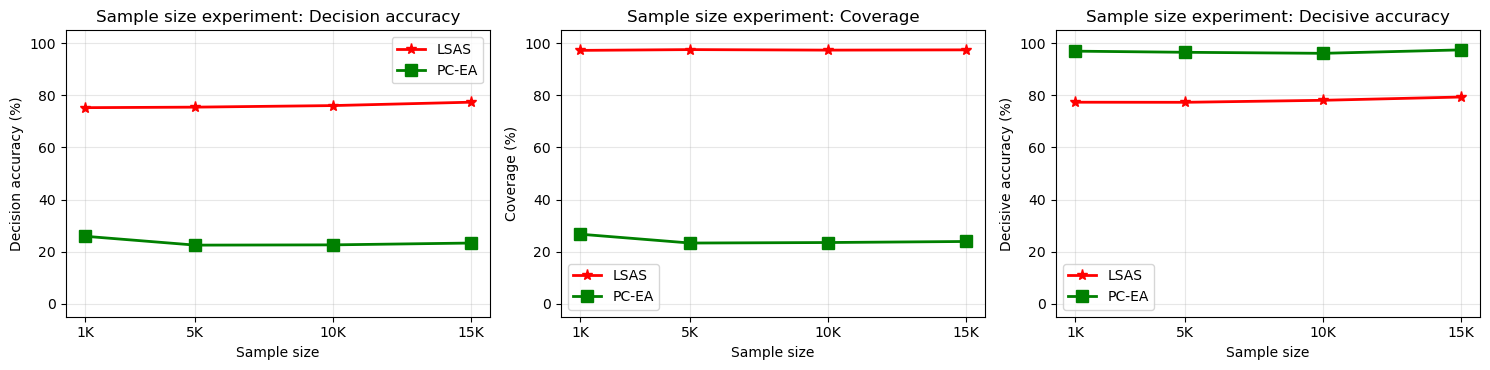

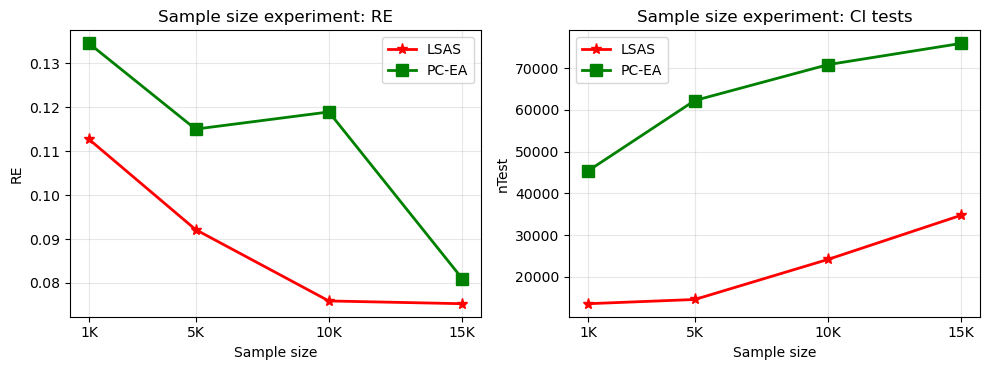

In [54]:
plot_experiment_metrics(
    decision_df=sample_size_decision_metrics,
    effect_df=sample_size_effect_effort,
    x_col="sample_size",
    x_label="Sample size",
    title_prefix="Sample size experiment",
)


## 2. Graph Size Experiment


In [55]:
graph_size_results_list = []

for graph_size in graph_sizes:
    results_one_graph_size = run_structure_experiment(
        structure_name=f"Graph size experiment, n_obs={graph_size}",
        sample_sizes=[BASE_SAMPLE_SIZE],
        n_reps=BASE_N_REPS,
        n_obs=graph_size,
        p=p_for_size(graph_size),
        beta=BASE_BETA,
        ci_method=BASE_CI_METHOD,
        )
    results_one_graph_size["graph_size"] = graph_size
    graph_size_results_list.append(results_one_graph_size)

graph_size_results = pd.concat(graph_size_results_list, ignore_index=True)
graph_size_results


Running Graph size experiment, n_obs=50 with sample size 5000 for 1000 reps...


Processing Graph size experiment, n_obs=50: 100%|██████████| 1000/1000 [17:50<00:00,  1.07s/it] 


Running Graph size experiment, n_obs=75 with sample size 5000 for 1000 reps...


Processing Graph size experiment, n_obs=75: 100%|██████████| 1000/1000 [52:02<00:00,  3.12s/it]  


Running Graph size experiment, n_obs=100 with sample size 5000 for 1000 reps...


Processing Graph size experiment, n_obs=100: 100%|██████████| 1000/1000 [2:13:31<00:00,  8.01s/it]   


Running Graph size experiment, n_obs=125 with sample size 5000 for 1000 reps...


Processing Graph size experiment, n_obs=125: 100%|██████████| 1000/1000 [4:06:26<00:00, 14.79s/it]   


,method,structure,sample_size,rep,true_decision,decision,decision_correct,is_decisive,true_ce,estimated_ce,...,MB_y,actual_MB_x,actual_MB_y,x_degree,y_degree,avg_xy_degree,p,beta,noise_scale,graph_size
0,PC-EA,"Graph size experiment, n_obs=50",5000,0,+,0,False,True,1.059449,0.000000,...,"[V27, V29, V32]","[V27, V3, V32, outcome]","[V27, V3, V32, treatment]",1,4,2.5,0.049020,0,1.0,50
1,LSAS,"Graph size experiment, n_obs=50",5000,0,+,?,False,False,1.059449,NaN,...,"[V3, V27, V32, treatment]","[V27, V3, V32, outcome]","[V27, V3, V32, treatment]",1,4,2.5,0.049020,0,1.0,50
2,PC-EA,"Graph size experiment, n_obs=50",5000,1,0,?,False,False,0.000000,NaN,...,"[V23, V30]","[V19, V2, V21, V29, V33]","[V23, V30]",5,2,3.5,0.049020,0,1.0,50
3,LSAS,"Graph size experiment, n_obs=50",5000,1,0,+,False,True,0.000000,0.133725,...,"[V16, V20, V23, V30, V35, V38]","[V19, V2, V21, V29, V33]","[V23, V30]",5,2,3.5,0.049020,0,1.0,50
4,PC-EA,"Graph size experiment, n_obs=50",5000,2,+,+,True,True,2.843668,3.323144,...,"[V28, V34, V37, V45, V47]","[V14, V28, V34, V37, V40, V43, V45, V47, outcome]","[V28, V34, V37, V45, V47, treatment]",5,6,5.5,0.049020,0,1.0,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,LSAS,"Graph size experiment, n_obs=125",5000,997,0,0,True,True,0.000000,0.000000,...,"[V9, V30, V38, V43, V63, V64, V68, V73, V112]",[V78],"[V112, V30, V64]",1,3,2.0,0.019841,0,1.0,125
7996,PC-EA,"Graph size experiment, n_obs=125",5000,998,+,?,False,False,2.956460,NaN,...,"[V122, V51]","[V103, V122, V19, V43, V51, outcome]","[V122, V51, treatment]",4,3,3.5,0.019841,0,1.0,125
7997,LSAS,"Graph size experiment, n_obs=125",5000,998,+,+,True,True,2.956460,2.955613,...,"[V33, V38, V43, V51, V122, treatment]","[V103, V122, V19, V43, V51, outcome]","[V122, V51, treatment]",4,3,3.5,0.019841,0,1.0,125
7998,PC-EA,"Graph size experiment, n_obs=125",5000,999,0,?,False,False,0.000000,NaN,...,[V91],"[V21, V59, V69]",[V91],3,1,2.0,0.019841,0,1.0,125


In [61]:
graph_size_decision_metrics = (
    graph_size_results
    .groupby(["method", "graph_size"], as_index=False)
    .agg(
        decision_acc=("decision_correct", "mean"),
        coverage=("is_decisive", "mean"),
        n_reps=("decision", "size"),
    )
)

graph_size_decisive_metrics = (
    graph_size_results[graph_size_results["is_decisive"]]
    .groupby(["graph_size", "method"], as_index=False)
    .agg(
        decisive_acc=("decision_correct", "mean"),
        n_decisive=("decision", "size"),
    )
)

graph_size_decision_metrics = graph_size_decision_metrics.merge(
    graph_size_decisive_metrics,
    on=["graph_size", "method"],
    how="left",
)

graph_size_decision_metrics["n_decisive"] = graph_size_decision_metrics["n_decisive"].fillna(0).astype(int)

graph_size_decision_metrics


,method,graph_size,decision_acc,coverage,n_reps,decisive_acc,n_decisive
0,LSAS,50,0.835,0.955,1000,0.874346,955
1,LSAS,75,0.852,0.960,1000,0.887500,960
2,LSAS,100,0.834,0.962,1000,0.866944,962
3,LSAS,125,0.863,0.969,1000,0.890609,969
4,PC-EA,50,0.391,0.405,1000,0.965432,405
5,PC-EA,75,0.403,0.409,1000,0.985330,409
6,PC-EA,100,0.407,0.418,1000,0.973684,418
7,PC-EA,125,0.410,0.421,1000,0.973872,421


In [60]:
graph_size_effect_effort = (
    graph_size_results
    .groupby(["method", "graph_size"], as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

graph_size_effect_effort


,method,graph_size,mean_RE,std_RE,mean_nTest,std_nTest
0,LSAS,50,0.040544,0.112423,3736.260,32733.084748
1,LSAS,75,0.046755,0.129787,20977.730,149622.747174
2,LSAS,100,0.050669,0.159235,62804.036,460323.217517
3,LSAS,125,0.043605,0.134048,130507.916,654018.742878
4,PC-EA,50,0.133699,0.296125,16152.132,7645.044856
5,PC-EA,75,0.071575,0.215888,33678.728,14374.971903
6,PC-EA,100,0.096877,0.270456,58783.003,21332.947907
7,PC-EA,125,0.111362,0.290424,91528.414,30890.201746


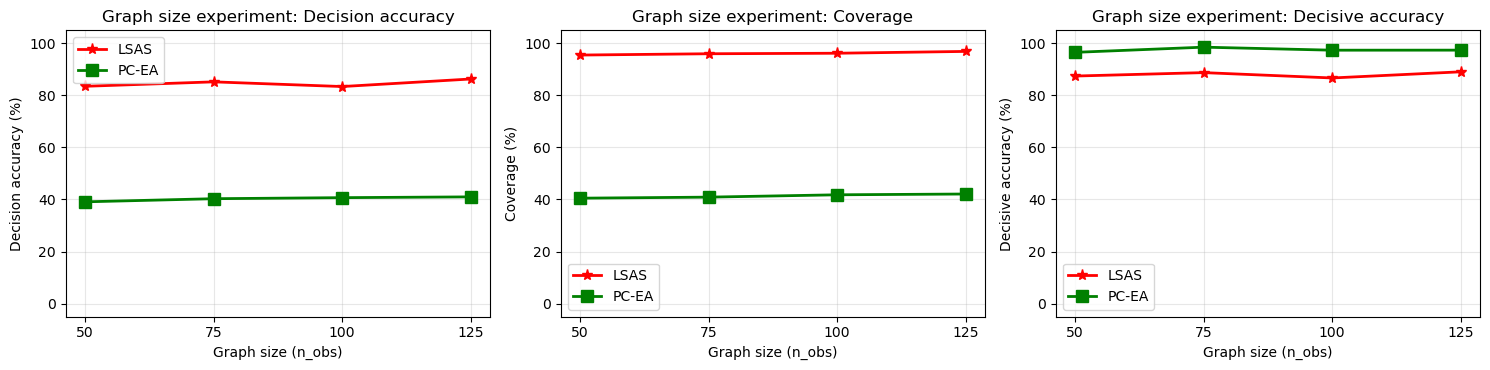

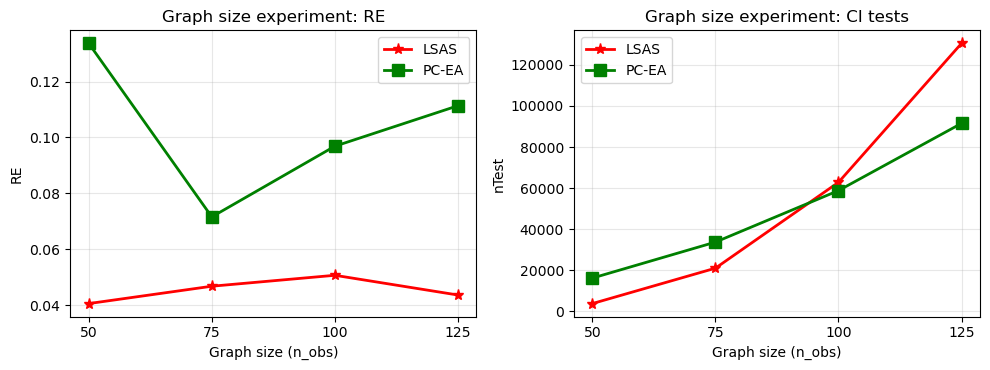

In [58]:
plot_experiment_metrics(
    decision_df=graph_size_decision_metrics,
    effect_df=graph_size_effect_effort,
    x_col="graph_size",
    x_label="Graph size (n_obs)",
    title_prefix="Graph size experiment",
)


## 3. Nonlinearity Experiment


In [59]:
beta_results_list = []

for beta_value in beta_values:
    results_one_beta = run_structure_experiment(
        structure_name=f"Nonlinearity experiment, beta={beta_value}",
        sample_sizes=[BASE_SAMPLE_SIZE],
        n_reps=BASE_N_REPS,
        n_obs=BASE_N_OBS,
        p=BASE_P,
        beta=beta_value,
        ci_method=BASE_CI_METHOD,
        )
    results_one_beta["beta_value"] = beta_value
    beta_results_list.append(results_one_beta)

beta_results = pd.concat(beta_results_list, ignore_index=True)
beta_results


Running Nonlinearity experiment, beta=0 with sample size 5000 for 1000 reps...


Processing Nonlinearity experiment, beta=0:   1%|          | 11/1000 [01:02<1:33:11,  5.65s/it]


KeyboardInterrupt: 

In [ ]:
beta_decision_metrics = (
    beta_results
    .groupby(["beta_value", "method"], as_index=False)
    .agg(
        decision_acc=("decision_correct", "mean"),
        coverage=("is_decisive", "mean"),
        n_reps=("decision", "size"),
    )
)

beta_decisive_metrics = (
    beta_results[beta_results["is_decisive"]]
    .groupby(["beta_value", "method"], as_index=False)
    .agg(
        decisive_acc=("decision_correct", "mean"),
        n_decisive=("decision", "size"),
    )
)

beta_decision_metrics = beta_decision_metrics.merge(
    beta_decisive_metrics,
    on=["beta_value", "method"],
    how="left",
)

beta_decision_metrics["n_decisive"] = beta_decision_metrics["n_decisive"].fillna(0).astype(int)

beta_decision_metrics


In [ ]:
beta_effect_effort = (
    beta_results
    .groupby(["beta_value", "method"], as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

beta_effect_effort


In [ ]:
plot_experiment_metrics(
    decision_df=beta_decision_metrics,
    effect_df=beta_effect_effort,
    x_col="beta_value",
    x_label="Beta",
    title_prefix="Nonlinearity experiment",
)
